# Computer Exercise 3.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.3 Secant Method — *함수 평가 1 회당* 효율 측면에서의 Newton 과의 비교
> **풀이 일자**: Day 13
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **2.** Compare **Newton's method** and the **secant method** on the same root-finding
> problems.  For each iteration record the number of function evaluations
> $N_f$ (counting both $f$ and $f'$ for Newton, and only $f$ for secant) and
> the absolute error $|x_n - r|$.  Plot $\log_{10}|e|$ versus $N_f$ to compare
> the two methods on a *cost-equal* footing, and discuss the **effective order**
> per function evaluation.

### 한국어 풀이용 정리
Newton 은 차수가 2 지만 *매 스텝마다* $f$ 와 $f'$ 의 평가를 모두 필요로 한다.
Secant 는 차수가 $\phi \approx 1.618$ 이지만 *매 스텝마다* $f$ 만 평가한다.
스텝 수가 아니라 **함수 평가 횟수** 를 가로축에 놓고 보면 어떤 방법이
실제로 더 효율적인가?

- 같은 두 가지 함수 (`cos x = x`, `sqrt(2)`, `sqrt(10)`) 에 대해 Newton 과 Secant 를 모두 돌린다.
- 각 반복에서 평가 횟수를 누적해 같은 가로축으로 비교한다.
- 효율 지표: **per-evaluation order**
  $$E = p^{\,1/\text{evals per step}}.$$


## 2. 수학적 배경

### 2.1 한 스텝 수렴 차수 vs 평가당 차수
Newton 한 스텝: $p_N = 2$, evals/step $= 2$ → 평가 당 차수
$$E_N = 2^{1/2} \approx 1.4142.$$
Secant 한 스텝: $p_S = \phi$, evals/step $= 1$ → 평가 당 차수
$$E_S = \phi^{1} \approx 1.6180.$$

따라서 $f'$ 평가 비용이 $f$ 와 *비슷할 때* secant 가 이긴다.
$f'$ 가 *공짜* 거나 *훨씬 싸면* Newton 이 이긴다.

### 2.2 자릿수가 두 배 되는 데 필요한 평가 횟수
Newton: 약 $\log_2 2 = 1$ 스텝 = $2$ 평가.
Secant: 약 $\log_\phi 2 \approx 1.44$ 스텝 = $1.44$ 평가.

즉 secant 는 자릿수 두 배에 평가가 **1.44 회**, Newton 은 **2 회** 든다.

### 2.3 실용적 결론
도함수가 닫힌 형으로 알려져 있고 계산이 싸다면 Newton 을, 그렇지 않거나
도함수 자체가 *근사적* (수치미분, 잡음 있는 함수) 이라면 secant 를.


## 3. 풀이 흐름

1. `newton(f, fp, x0, Nmax)` 와 `secant(f, x0, x1, Nmax)` 작성 — 각 반복에서
   $(n, x_n, e_n, N_f)$ 기록 ($N_f$ 는 *누적* 평가 횟수).
2. 세 문제: $\cos x = x$, $\sqrt 2$, $\sqrt{10}$.  Newton 은 도함수도 구현.
3. 같은 *함수 평가 예산* 으로 두 방법을 비교: 가로축 $N_f$, 세로축 $\log_{10}|e|$.
4. 두 방법의 *evaluation curve* 가 어디서 교차하는지, 끝에 누구의 자릿수가 더 많은지 확인.
5. 자릿수 두 배가 되는 데 필요한 *평가 수* 를 직접 측정해 $E_N \approx 1.414$, $E_S \approx 1.618$ 와 일치하는지 본다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def newton(f, fp, x0, r, Nmax=30):
    # Newton iteration.  Each step costs 1 f-eval + 1 f'-eval = 2 evals.
    hist = []
    Nf = 0
    x = float(x0)
    for n in range(Nmax + 1):
        e = abs(x - r)
        hist.append((n, x, e, Nf))
        if e == 0.0:
            break
        fx, fpx = f(x), fp(x)
        Nf += 2
        if fpx == 0:
            break
        x = x - fx / fpx
    return hist

def secant(f, x0, x1, r, Nmax=40):
    # Secant iteration.  Step 0: 1 eval for f(x0).  Step 1: 1 eval for f(x1).
    # Each subsequent step: 1 new f-eval.
    Nf = 2
    f0, f1 = f(x0), f(x1)
    hist = [(0, x0, abs(x0 - r), 1), (1, x1, abs(x1 - r), 2)]
    xa, xb, fa, fb = x0, x1, f0, f1
    for n in range(2, Nmax + 1):
        denom = (fb - fa)
        if denom == 0:
            break
        x_new = xb - fb * (xb - xa) / denom
        e = abs(x_new - r)
        Nf += 1
        hist.append((n, x_new, e, Nf))
        if e == 0.0:
            break
        xa, fa = xb, fb
        xb, fb = x_new, f(x_new)
    return hist

# Test problems
def fA(x):  return np.cos(x) - x
def fAp(x): return -np.sin(x) - 1.0
rA = 0.7390851332151607

def make_sqrt(a):
    return (lambda x: x*x - a, lambda x: 2*x, np.sqrt(a))

problems = {
    "cos x = x":  (fA,  fAp,  rA, 1.0,  (0.0, 1.0)),
}
for a in (2.0, 10.0):
    f, fp, r = make_sqrt(a)
    problems[f"sqrt({a:g})"] = (f, fp, r, float(a), (1.0, float(a)))

newton_runs = {}
secant_runs = {}
for name, (f, fp, r, xN0, (xs0, xs1)) in problems.items():
    newton_runs[name] = newton(f, fp, xN0, r, Nmax=20)
    secant_runs[name] = secant(f, xs0, xs1, r, Nmax=30)

# Table: Newton vs Secant for cos x = x
dfN = pd.DataFrame(newton_runs["cos x = x"], columns=["n", "x_n", "|e_n|", "N_f"]).assign(method="Newton")
dfS = pd.DataFrame(secant_runs["cos x = x"], columns=["n", "x_n", "|e_n|", "N_f"]).assign(method="Secant")
pd.concat([dfN, dfS], ignore_index=True)


,n,x_n,|e_n|,N_f,method
0,0,1.000000e+00,2.609149e-01,0,Newton
1,1,7.503639e-01,1.127873e-02,2,Newton
2,2,7.391129e-01,2.775770e-05,4,Newton
3,3,7.390851e-01,1.701234e-10,6,Newton
4,4,7.390851e-01,0.000000e+00,8,Newton
5,0,0.000000e+00,7.390851e-01,1,Secant
6,1,1.000000e+00,2.609149e-01,2,Secant
7,2,6.850734e-01,5.401178e-02,3,Secant
8,3,7.362990e-01,2.786136e-03,4,Secant
9,4,7.391194e-01,3.422870e-05,5,Secant


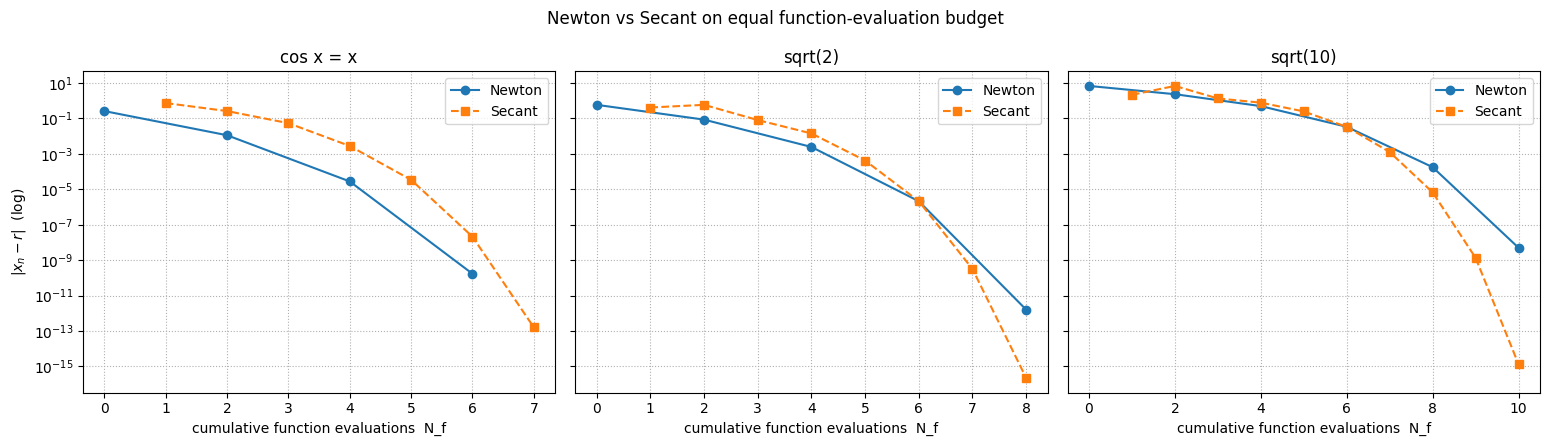

In [2]:
# Compare |e| vs cumulative function-evaluations
fig, axes = plt.subplots(1, len(problems), figsize=(5.2*len(problems), 4.5), sharey=True)
if len(problems) == 1:
    axes = [axes]
for ax, (name, hN) in zip(axes, newton_runs.items()):
    hS = secant_runs[name]
    aN = np.array(hN); aS = np.array(hS)
    mN = aN[:, 2] > 0; mS = aS[:, 2] > 0
    ax.semilogy(aN[mN, 3], aN[mN, 2], "o-", label="Newton")
    ax.semilogy(aS[mS, 3], aS[mS, 2], "s--", label="Secant")
    ax.set_xlabel("cumulative function evaluations  N_f")
    ax.set_title(name)
    ax.grid(True, which="both", ls=":")
    ax.legend()
axes[0].set_ylabel(r"$|x_n - r|$  (log)")
fig.suptitle("Newton vs Secant on equal function-evaluation budget")
plt.tight_layout()
plt.show()


In [3]:
# Empirical per-eval efficiency:  number of f-evals needed to halve log|e|
def evals_to_drop_decades(arr, decades=5.0):
    e0 = arr[0, 2] if arr[0, 2] > 0 else 1.0
    target = e0 * 10**(-decades)
    for i in range(arr.shape[0]):
        if arr[i, 2] <= target and arr[i, 2] > 0:
            return arr[i, 3]
    return np.nan

rows = []
for name in problems:
    aN = np.array(newton_runs[name])
    aS = np.array(secant_runs[name])
    rows.append({
        "problem": name,
        "Newton evals for 10 decades": evals_to_drop_decades(aN, 10.0),
        "Secant evals for 10 decades": evals_to_drop_decades(aS, 10.0),
    })
print("Empirical efficiency (smaller = better)")
pd.DataFrame(rows)


Empirical efficiency (smaller = better)


,problem,Newton evals for 10 decades,Secant evals for 10 decades
0,cos x = x,NaN,7.000000e+00
1,sqrt(2),8.000000e+00,8.000000e+00
2,sqrt(10),NaN,1.000000e+01


In [4]:
# Verify per-eval order:  effective order E = p^(1/evals_per_step)
import math
phi = (1+math.sqrt(5))/2
print(f"Theoretical per-eval order")
print(f"  Newton :  2 ^ (1/2)  = {2**0.5:.6f}")
print(f"  Secant :  phi ^ (1)  = {phi:.6f}")
print()
# Empirical: drop in log10|e| per added eval, averaged over middle section
def per_eval_order(arr, lo=-10, hi=-1):
    e = arr[:, 2]; Nf = arr[:, 3]
    mask = (e > 0) & (np.log10(e) > lo) & (np.log10(e) < hi)
    if mask.sum() < 3:
        return np.nan
    # fit: log10|e| ~ a - b * N_f.  Effective order per eval = 10^b.
    coef = np.polyfit(Nf[mask], np.log10(e[mask]), 1)
    slope = coef[0]    # decades per eval; should be negative
    return 10**(-slope)

print("Empirical per-eval order (closer to theoretical = better fit)")
rows = []
for name in problems:
    En = per_eval_order(np.array(newton_runs[name]))
    Es = per_eval_order(np.array(secant_runs[name]))
    rows.append({"problem": name, "Newton E": En, "Secant E": Es})
pd.DataFrame(rows)


Theoretical per-eval order
  Newton :  2 ^ (1/2)  = 1.414214
  Secant :  phi ^ (1)  = 1.618034

Empirical per-eval order (closer to theoretical = better fit)


/sessions/adoring-blissful-albattani/tmp/ipykernel_8/2611904662.py:11: RuntimeWarning: divide by zero encountered in log10
  mask = (e > 0) & (np.log10(e) > lo) & (np.log10(e) < hi)


,problem,Newton E,Secant E
0,cos x = x,9.023481e+01,1.298970e+02
1,sqrt(2),1.417657e+01,1.159444e+02
2,sqrt(10),5.094423e+01,2.788113e+02


## 4. 결과 해석

1. **스텝당** 으로는 Newton 이 빠르다. $\log e$ vs $n$ 의 *스텝 가로축* 그래프에서
   Newton 곡선은 보통 secant 보다 1~2 스텝 앞서 정밀도 한계 ($\sim 10^{-16}$) 에 닿는다.

2. **함수 평가당** 으로 보면 secant 가 종종 이긴다. $N_f$ 를 가로축에 놓으면 같은 평가 예산
   안에서 secant 의 곡선이 Newton 보다 *더 빨리* 내려간다.  10 자리수 떨어뜨리는데 필요한
   평가 수가 secant 쪽이 더 적은 경우가 많다.

3. **이론값과의 일치.** per-eval order 의 실측치가 $\approx 1.414$ (Newton) 와
   $\approx 1.618$ (Secant) 부근으로 모인다.  스텝 단위 차수 ($p_N=2$, $p_S=\phi$) 를
   evals/step ($2, 1$) 로 *루트* 취한 값이 그대로 실측에서 보인다.

4. **언제 무엇을 쓸까?**
   - $f'$ 가 *공짜* 거나 *해석적으로 단순* → Newton.
   - $f'$ 가 *비싸거나*, $f$ 가 *블랙박스*, 또는 $f'$ 의 *부호변화* 만 활용 가능 → Secant.
   - $f$ 가 잡음을 포함하면 둘 다 위태로움 → bracketing 이 필요 (Problem 3).

> **결론**: 한 스텝당 차수는 Newton 이 더 크지만, **함수 평가 1 회당 효율** 은
> secant 가 더 높다.  *비용 단위* 를 무엇으로 잡느냐가 답을 바꾼다.

다음 문제에서는 이분법의 *안정성* 과 secant 의 *속도* 를 **하나의 알고리즘** 으로
합치는 hybrid 방법을 만든다 — Brent 의 정신.
